In [ ]:
#!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 37.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
import pmdarima as pm
import statsmodels.api as sm

In [ ]:
#Data de Atenciones de Urgencias de la DEIS
#ruta_au2021 = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\AtencionesUrgencia\AtencionesUrgResp_2021.csv"
#ruta_au2022 = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\AtencionesUrgencia\AtencionesUrgResp_2022.csv"
#ruta_au2023 = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\AtencionesUrgencia\AtencionesUrgResp_2023.csv"
#ruta_au2024 = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\AtencionesUrgencia\AtencionesUrgResp_2024.csv"
#ruta_au2025 = r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\AtencionesUrgencia\AtencionesUrgResp_2025.csv"

#Si archivo se corre en VS se debe colocar la ruta reemplazando el nombre del archivp

au_2021_df = pd.read_csv('AtencionesUrgResp_2021.csv', encoding='latin-1', sep=',', dtype={'IdEstablecimiento': str},low_memory=True) #df de las atenciones de urgencia 2021
au_2022_df = pd.read_csv('AtencionesUrgResp_2022.csv', encoding='latin-1', sep=',', dtype={'IdEstablecimiento': str},low_memory=True) #df de las atenciones de urgencia 2022
au_2023_df = pd.read_csv('AtencionesUrgResp_2023.csv', encoding='latin-1', sep=',', dtype={'IdEstablecimiento': str},low_memory=True) #df de las atenciones de urgencia 2023
au_2024_df = pd.read_csv('AtencionesUrgResp_2024.csv', encoding='latin-1', sep=',', dtype={'IdEstablecimiento': str},low_memory=True) #df de las atenciones de urgencia 2024
au_2025_df = pd.read_csv('AtencionesUrgResp_2025(1).csv', encoding='latin-1', sep=',', dtype={'IdEstablecimiento': str},low_memory=True) #df de las atenciones de urgencia 2025


In [ ]:
#Listado de Establecimientos de Salud del MINSAL
#ruta_establecimientos= r"C:\Users\Javiera Baeza\Dropbox\MACI\Clases MACI 2024\TESINA\DATA Y CODIGOS\EstablecimientosSalud\Establecimientos DEIS MINSAL 22-10-2025.xlsx"

est_df = pd.read_excel('Establecimientos DEIS MINSAL 22-10-2025.xlsx', sheet_name='ESTABLECIMIENTO_2025-10-22',header=1) #df de los establecimientos de salud

In [ ]:
#Analizamos la data de cada df
au_2021_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220406 entries, 0 to 220405
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   IdEstablecimiento         220406 non-null  object
 1   NEstablecimiento          220406 non-null  object
 2   IdCausa                   220406 non-null  int64 
 3   GlosaCausa                220406 non-null  object
 4   Total                     220406 non-null  int64 
 5   Menores_1                 220406 non-null  int64 
 6   De_1_a_4                  220406 non-null  int64 
 7   De_5_a_14                 220406 non-null  int64 
 8   De_15_a_64                220406 non-null  int64 
 9   De_65_y_mas               220406 non-null  int64 
 10  fecha                     220406 non-null  object
 11  semana                    220406 non-null  int64 
 12  GLOSATIPOESTABLECIMIENTO  220406 non-null  object
 13  GLOSATIPOATENCION         220406 non-null  object
 14  Glos

In [ ]:
#Analizamos la data de cada df
au_2022_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223158 entries, 0 to 223157
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   IdEstablecimiento         223158 non-null  object
 1   NEstablecimiento          223158 non-null  object
 2   IdCausa                   223158 non-null  int64 
 3   GlosaCausa                223158 non-null  object
 4   Total                     223158 non-null  int64 
 5   Menores_1                 223158 non-null  int64 
 6   De_1_a_4                  223158 non-null  int64 
 7   De_5_a_14                 223158 non-null  int64 
 8   De_15_a_64                223158 non-null  int64 
 9   De_65_y_mas               223158 non-null  int64 
 10  fecha                     223158 non-null  object
 11  semana                    223158 non-null  int64 
 12  GLOSATIPOESTABLECIMIENTO  223158 non-null  object
 13  GLOSATIPOATENCION         223158 non-null  object
 14  Glos

In [ ]:
#Analizamos la data de cada df
au_2023_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222477 entries, 0 to 222476
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   IdEstablecimiento         222477 non-null  object
 1   NEstablecimiento          222477 non-null  object
 2   IdCausa                   222477 non-null  int64 
 3   GlosaCausa                222477 non-null  object
 4   Total                     222477 non-null  int64 
 5   Menores_1                 222477 non-null  int64 
 6   De_1_a_4                  222477 non-null  int64 
 7   De_5_a_14                 222477 non-null  int64 
 8   De_15_a_64                222477 non-null  int64 
 9   De_65_y_mas               222477 non-null  int64 
 10  fecha                     222477 non-null  object
 11  semana                    222477 non-null  int64 
 12  GLOSATIPOESTABLECIMIENTO  222477 non-null  object
 13  GLOSATIPOATENCION         222477 non-null  object
 14  Glos

In [ ]:
#Analizamos la data de cada df
au_2024_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224330 entries, 0 to 224329
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IdEstablecimiento         224330 non-null  object 
 1   NEstablecimiento          223039 non-null  object 
 2   IdCausa                   224330 non-null  int64  
 3   GlosaCausa                224330 non-null  object 
 4   Total                     224330 non-null  int64  
 5   Menores_1                 224330 non-null  int64  
 6   De_1_a_4                  224330 non-null  int64  
 7   De_5_a_14                 224330 non-null  int64  
 8   De_15_a_64                224330 non-null  int64  
 9   De_65_y_mas               224330 non-null  int64  
 10  fecha                     224330 non-null  object 
 11  semana                    224330 non-null  int64  
 12  GLOSATIPOESTABLECIMIENTO  224330 non-null  object 
 13  GLOSATIPOATENCION         224330 non-null  o

In [ ]:
#Analizamos la data de cada df
au_2025_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226109 entries, 0 to 226108
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IdEstablecimiento         226109 non-null  object 
 1   NEstablecimiento          224994 non-null  object 
 2   IdCausa                   226109 non-null  int64  
 3   GlosaCausa                226109 non-null  object 
 4   Total                     226109 non-null  int64  
 5   Menores_1                 226109 non-null  int64  
 6   De_1_a_4                  226109 non-null  int64  
 7   De_5_a_14                 226109 non-null  int64  
 8   De_15_a_64                226109 non-null  int64  
 9   De_65_y_mas               226109 non-null  int64  
 10  fecha                     226109 non-null  object 
 11  semana                    226109 non-null  int64  
 12  GLOSATIPOESTABLECIMIENTO  226109 non-null  object 
 13  GLOSATIPOATENCION         226109 non-null  o

In [ ]:
#Analizamos la data de cada df
est_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5066 entries, 0 to 5065
Data columns (total 32 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Código Antiguo                                              5066 non-null   object 
 1   Código Vigente                                              5066 non-null   int64  
 2   Código  Madre Antiguo                                       938 non-null    object 
 3   Código Madre Nuevo                                          934 non-null    object 
 4   Código Región                                               5066 non-null   int64  
 5   Nombre Región                                               5066 non-null   object 
 6   Código Dependencia Jerárquica (SEREMI / Servicio de Salud)  5066 non-null   int64  
 7   Nombre Dependencia Jerárquica (SEREMI / Servicio de Salud)  5066 non-null   object 
 8 

In [ ]:
#Analizamos el df de establecimientos, eliminamos las columnas que no nos sirven en este análisis
columnas_a_eliminar1 = [
    'Código Vigente',
    'Código  Madre Antiguo',
    'Código Madre Nuevo',
    'Código Dependencia Jerárquica (SEREMI / Servicio de Salud)',
    'Nombre Dependencia Jerárquica (SEREMI / Servicio de Salud)',
    'Pertenencia al SNSS',
    'Tipo Establecimiento (Unidad)',
    'Certificación ',
    'Ámbito de Funcionamiento',
    'Dependencia Administrativa',
    'Nivel de Atención',
    'Vía',
    'Número',
    'Dirección',
    'Teléfono',
    'Fecha Inicio Funcionamiento',
    'Tiene Servicio de Urgencia',
    'Tipo de Urgencia ',
    'Clasificación Tipo de SAPU',
    'Tipo de Prestador Sistema de Salud',
    'Estado de Funcionamiento',
    'Nivel de Complejidad',
    'Tipo de Atención ',
    'Fecha de Incorporación a la base '
]

est_df.drop(columns=columnas_a_eliminar1, inplace=True)
est_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5066 entries, 0 to 5065
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Código Antiguo               5066 non-null   object 
 1   Código Región                5066 non-null   int64  
 2   Nombre Región                5066 non-null   object 
 3   Nombre Oficial               5066 non-null   object 
 4   Código Comuna                5063 non-null   float64
 5   Nombre Comuna                5066 non-null   object 
 6   LATITUD [Grados decimales]   4999 non-null   object 
 7   LONGITUD [Grados decimales]  4999 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 316.8+ KB


In [ ]:
#Debemos renombrar columnas de est_df para poder realizar el cruce con los df de las atenciones de urgencia
columnas_a_renombrar = {
    'Código Antiguo ': 'IdEstablecimiento',
    'Código Región': 'CodigoRegion',
    'Nombre Región': 'NombreRegion',
    'Nombre Oficial': 'NEstablecimiento',
    'Código Comuna': 'CodigoComuna',
    'Nombre Comuna': 'NombreComuna'
}
# Renombramos las columnas
est_df.rename(columns=columnas_a_renombrar, inplace=True)

# Eliminar duplicados para evitar problemas en el cruce
est_df.drop_duplicates(subset=['IdEstablecimiento'], inplace=True)

# Verificamos que el renombramiento se realizó correctamente
print(est_df.columns)

Index(['IdEstablecimiento', 'CodigoRegion', 'NombreRegion', 'NEstablecimiento',
       'CodigoComuna', 'NombreComuna', 'LATITUD [Grados decimales]',
       'LONGITUD [Grados decimales]'],
      dtype='object')


In [ ]:
est_df

,IdEstablecimiento,CodigoRegion,NombreRegion,NEstablecimiento,CodigoComuna,NombreComuna,LATITUD [Grados decimales],LONGITUD [Grados decimales]
0,26-704,12,Región de Magallanes y de la Antártica Chilena,Hospital Comunitario Cristina Calderón de Puer...,12201.0,Cabo de Hornos,-54.93521,-67.60039
1,26-204,12,Región de Magallanes y de la Antártica Chilena,Hospital Naval (Puerto Williams),12201.0,Cabo de Hornos,-54.934374,-67.608895
2,26-412,12,Región de Magallanes y de la Antártica Chilena,Posta de Salud Rural Cameron,12303.0,Timaukel,-53.64055,-69.64585
3,26-414,12,Región de Magallanes y de la Antártica Chilena,Posta de Salud Rural Agua Fresca,12101.0,Punta Arenas,-53.40424,-70.99016
4,26-102,12,Región de Magallanes y de la Antártica Chilena,Hospital Dr. Marco Antonio Chamorro (Porvenir),12301.0,Porvenir,-53.29816,-70.35838
...,...,...,...,...,...,...,...,...
5061,202128,13,Región Metropolitana de Santiago,CENTRO MEDICO HTS,NaN,LAS CONDES,NaN,NaN
5062,202129,13,Región Metropolitana de Santiago,UNO SALUD LA FLORIDA SANTA AMALIA,13110.0,La Florida,NaN,NaN
5063,202130,13,Región Metropolitana de Santiago,UNO SALUD DENTAL RECOLETA,NaN,Recoleta,NaN,NaN
5064,202131,13,Región Metropolitana de Santiago,UNO SALUD DENTAL PLAZA EGAÑA,NaN,Ñuñoa,NaN,NaN


Aquí comenzaremos a trabajar cada data de atenciones de urgencia para luego poder realizar una limpieza de datos, se debe considerar que las AtencionesUrgencia de 2021 y 2022 no tienen las mismas columnas que los años 2023, 2024 y 2025, por que se deberá realizar un análisis para estandarizar la data.

Columnas que no contiene 2021 y 2022 'CodigoRegion', 'NombreRegion', 'NEstablecimiento','CodigoComuna', 'NombreComuna'

In [ ]:
# Columnas específicas del est_df que queremos añadir a la data de atenciones
columnas_est_a_cruzar = [
    'IdEstablecimiento',
    'CodigoRegion',
    'NombreRegion',
    'CodigoComuna',
    'NombreComuna'
]

# Realizamos el Left Merge para añadir la data geográfica a au_2021_df
au_2021_merged = au_2021_df.merge(
    est_df[columnas_est_a_cruzar],
    on='IdEstablecimiento',
    how='left',
    suffixes=('_au', '_est')
)

# 1. Conteo de Registros Sin Match
# Un registro NO hizo match si el 'CodigoRegion' es NaN después del merge.
no_match_2021 = au_2021_merged['CodigoRegion'].isna().sum()
total_registros_2021 = len(au_2021_merged)
porcentaje_no_match_2021 = (no_match_2021 / total_registros_2021) * 100

print(f"Total de registros de atenciones 2021: {total_registros_2021:,}")
print(f"Registros sin match geográfico (IdEstablecimiento no encontrado en est_df): {no_match_2021:,}")
print(f"Porcentaje de registros sin match: {porcentaje_no_match_2021:.4f}%")

Total de registros de atenciones 2021: 220,406
Registros sin match geográfico (IdEstablecimiento no encontrado en est_df): 16,111
Porcentaje de registros sin match: 7.3097%


In [ ]:
# Realizamos el Left Merge para añadir la data geográfica a au_2022_df
au_2022_merged = au_2022_df.merge(
    est_df[columnas_est_a_cruzar],
    on='IdEstablecimiento',
    how='left',
    suffixes=('_au', '_est')
)

# Conteo de Registros Sin Match
no_match_2022 = au_2022_merged['CodigoRegion'].isna().sum()
total_registros_2022 = len(au_2022_merged)
porcentaje_no_match_2022 = (no_match_2022 / total_registros_2022) * 100

print(f"Total de registros de atenciones 2022: {total_registros_2022:,}")
print(f"Registros sin match geográfico: {no_match_2022:,}")
print(f"Porcentaje de registros sin match: {porcentaje_no_match_2022:.4f}%")

Total de registros de atenciones 2022: 223,158
Registros sin match geográfico: 18,527
Porcentaje de registros sin match: 8.3022%


In [ ]:
# Establecimientos sin match en 2021
ids_2021_nomat = au_2021_df[~au_2021_df["IdEstablecimiento"].isin(est_df["IdEstablecimiento"])]["IdEstablecimiento"].unique()
print("Establecimientos sin match en 2021:", len(ids_2021_nomat))
print(ids_2021_nomat)

# Establecimientos sin match en 2022
ids_2022_nomat = au_2022_df[~au_2022_df["IdEstablecimiento"].isin(est_df["IdEstablecimiento"])]["IdEstablecimiento"].unique()
print("\nEstablecimientos sin match en 2022:", len(ids_2022_nomat))
print(ids_2022_nomat)

Establecimientos sin match en 2021: 50
['05-805 ' '13-190 ' '02-805' '05-809 ' '201043' '05-801 ' '05-802 '
 '05-817 ' '05-803 ' '16-840 ' '05-819 ' '02-924' '06-920' '02-806  '
 '19-912' '17-803' '02-923' '201063' '201079' '14-826 ' '05-804 ' '201067'
 '09-102 ' '05-822 ' '12-903' '22-200 ' '12-816 ' '06-916' '201070'
 '201085' '05-102 ' '21-803 ' '201069' '16-802 ' '07-802 ' '05-823 '
 '26-100 ' '33-150 ' '09-808 ' '22-201 ' '05-103 ' '201078' '23-801 '
 '09-890 ' '12-820' '02-925' '17-921' '19-808' '08-900' '07-905']

Establecimientos sin match en 2022: 55
['26-100 ' '201079' '05-103 ' '05-102 ' '05-804 ' '19-912' '17-803'
 '14-826 ' '13-190 ' '05-802 ' '05-819 ' '33-150 ' '09-102 ' '201063'
 '05-817 ' '22-200 ' '201043' '12-820' '05-805 ' '23-801 ' '05-822 '
 '201070' '09-808 ' '05-801 ' '201069' '17-921' '22-201 ' '21-803 '
 '05-823 ' '201147' '06-916' '02-924' '201038' '05-809 ' '201085'
 '16-840 ' '16-802 ' '02-806  ' '09-890 ' '05-803 ' '201187' '201078'
 '201067' '07-802 ' '02

In [ ]:
# Lista de códigos de establecimientos sin match en 2021
ids_2021_nomatch = ['05-805', '13-190', '02-805', '05-809', '201043', '05-801', '05-802', '05-817', '05-803', '16-840', '05-819', '02-924', '06-928', '02-806', '19-912', '17-803', '02-923', '201063', '201079', '14-826', '05-804', '201067', '09-102', '05-822', '12-903', '22-200', '12-816', '06-916', '201070', '201085', '05-102', '21-803', '201069', '16-802', '07-802', '05-823', '26-100', '33-150', '09-800', '22-201', '05-103', '201078', '23-801', '09-890', '12-820', '02-925', '17-921', '19-808', '08-900', '07-905']

# Filtramos est_df con los IDs sin match
nombres_2021 = est_df[est_df['IdEstablecimiento'].isin(ids_2021_nomatch)][['IdEstablecimiento', 'NEstablecimiento']]

print("Nombres de Establecimientos sin Match en 2021 (según est_df):")
print(nombres_2021)

Nombres de Establecimientos sin Match en 2021 (según est_df):
     IdEstablecimiento                                   NEstablecimiento
42              26-100  Hospital Clínico de Magallanes Dr. Lautaro Nav...
208             33-150                                 Hospital de Castro
466             23-801                                    SAPU Rahue Alto
675             22-201                            Hospital de Panguipulli
684             22-200   Hospital Santa Elisa de San José de la Mariquina
876             21-803                                     SAR Miraflores
1864            16-840                                   SAR Las Américas
1963            16-802                                SAR Bombero Garrido
2356            14-826                                 SAPU Karol Wojtyla
2414            13-190            Hospital Parroquial de San Bernardo (D)
2675            12-816                             SAR Carol Urzúa Ibáñez
2934            09-102  Instituto Psiquiátrico Dr.

In [ ]:
# Lista de códigos de establecimientos sin match en 2022
ids_2022_nomatch = ['26-100', '201079', '05-103', '05-102', '05-804', '19-912', '17-803', '14-826', '13-190', '05-802', '05-819', '33-150', '09-102', '201063', '05-817', '22-200', '201043', '12-820', '05-805', '23-801', '05-822', '201076', '09-800', '05-801', '201069', '17-921', '22-201', '21-803', '05-823', '201147', '06-916', '02-924', '201038', '05-809', '201085', '16-840', '16-802', '02-806', '09-890', '05-803', '201107', '201078', '201067', '07-802', '02-925', '201169', '12-816', '06-920', '201215', '201140', '02-923', '201194', '12-903', '07-905', '201178']

# Filtramos est_df con los IDs sin match
nombres_2022 = est_df[est_df['IdEstablecimiento'].isin(ids_2022_nomatch)][['IdEstablecimiento', 'NEstablecimiento']]

print("\nNombres de Establecimientos sin Match en 2022 (según est_df):")
print(nombres_2022)


Nombres de Establecimientos sin Match en 2022 (según est_df):
     IdEstablecimiento                                   NEstablecimiento
42              26-100  Hospital Clínico de Magallanes Dr. Lautaro Nav...
208             33-150                                 Hospital de Castro
466             23-801                                    SAPU Rahue Alto
675             22-201                            Hospital de Panguipulli
684             22-200   Hospital Santa Elisa de San José de la Mariquina
876             21-803                                     SAR Miraflores
1864            16-840                                   SAR Las Américas
1963            16-802                                SAR Bombero Garrido
2356            14-826                                 SAPU Karol Wojtyla
2414            13-190            Hospital Parroquial de San Bernardo (D)
2675            12-816                             SAR Carol Urzúa Ibáñez
2934            09-102  Instituto Psiquiátrico Dr

LIMPIEZA, para comenzar con la limpieza de los df los concatenaremos para luego limpiarlos

In [ ]:
au_2021_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220406 entries, 0 to 220405
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IdEstablecimiento         220406 non-null  object 
 1   NEstablecimiento          220406 non-null  object 
 2   IdCausa                   220406 non-null  int64  
 3   GlosaCausa                220406 non-null  object 
 4   Total                     220406 non-null  int64  
 5   Menores_1                 220406 non-null  int64  
 6   De_1_a_4                  220406 non-null  int64  
 7   De_5_a_14                 220406 non-null  int64  
 8   De_15_a_64                220406 non-null  int64  
 9   De_65_y_mas               220406 non-null  int64  
 10  fecha                     220406 non-null  object 
 11  semana                    220406 non-null  int64  
 12  GLOSATIPOESTABLECIMIENTO  220406 non-null  object 
 13  GLOSATIPOATENCION         220406 non-null  o

In [ ]:
#REORDENAMOS Y LIMPIAMOS
# Lista completa de columnas esperadas
columnas_finales = [
    'IdEstablecimiento', 'NEstablecimiento', 'IdCausa', 'GlosaCausa', 'Total',
    'Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas',
    'fecha', 'semana', 'GLOSATIPOESTABLECIMIENTO', 'GLOSATIPOATENCION', 'GlosaTipoCampana',
    'CodigoRegion', 'NombreRegion', 'CodigoComuna', 'NombreComuna'
]

#eliminamos las columnas que no son de nuestro interes

au_2023_df.drop(columns=['CodigoDependencia', 'NombreDependencia'], inplace=True)
au_2024_df.drop(columns=['CodigoDependencia', 'NombreDependencia'], inplace=True)
au_2025_df.drop(columns=['CodigoDependencia', 'NombreDependencia'], inplace=True)

au_2021_merged['Anio'] = 2021
au_2022_merged['Anio'] = 2022
au_2023_df['Anio'] = 2023
au_2024_df['Anio'] = 2024
au_2025_df['Anio'] = 2025

au_2021_merged = au_2021_merged[columnas_finales + ['Anio']]
au_2022_merged = au_2022_merged[columnas_finales + ['Anio']]
au_2023_df = au_2023_df[columnas_finales + ['Anio']]
au_2024_df = au_2024_df[columnas_finales + ['Anio']]
au_2025_df = au_2025_df[columnas_finales + ['Anio']]

In [ ]:
#Concatemaos todos los df

au_respiratorias = pd.concat([au_2021_merged, au_2022_merged, au_2023_df, au_2024_df, au_2025_df], ignore_index=True)
print("Información del DataFrame total consolidado:")
au_respiratorias.info()


Información del DataFrame total consolidado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116480 entries, 0 to 1116479
Data columns (total 20 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   IdEstablecimiento         1116480 non-null  object 
 1   NEstablecimiento          1114074 non-null  object 
 2   IdCausa                   1116480 non-null  int64  
 3   GlosaCausa                1116480 non-null  object 
 4   Total                     1116480 non-null  int64  
 5   Menores_1                 1116480 non-null  int64  
 6   De_1_a_4                  1116480 non-null  int64  
 7   De_5_a_14                 1116480 non-null  int64  
 8   De_15_a_64                1116480 non-null  int64  
 9   De_65_y_mas               1116480 non-null  int64  
 10  fecha                     1116480 non-null  object 
 11  semana                    1116480 non-null  int64  
 12  GLOSATIPOESTABLECIMIENTO  1116480 non-n

In [ ]:
#LIMPIEZA
#Cambiar tipo de dato d columna "fecha"

au_respiratorias['fecha']=pd.to_datetime(au_respiratorias['fecha'])
au_respiratorias

/tmp/ipython-input-119169151.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  au_respiratorias['fecha']=pd.to_datetime(au_respiratorias['fecha'])


,IdEstablecimiento,NEstablecimiento,IdCausa,GlosaCausa,Total,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas,fecha,semana,GLOSATIPOESTABLECIMIENTO,GLOSATIPOATENCION,GlosaTipoCampana,CodigoRegion,NombreRegion,CodigoComuna,NombreComuna,Anio
0,09-810,SAR Colina,2,TOTAL CAUSAS SISTEMA RESPIRATORIO,6,0,1,1,3,1,2021-01-21,3,SAR,Indiferenciado,Ninguna,13.0,Región Metropolitana de Santiago,13301.0,Colina,2021
1,09-810,SAR Colina,2,TOTAL CAUSAS SISTEMA RESPIRATORIO,10,0,1,3,4,2,2021-01-22,3,SAR,Indiferenciado,Ninguna,13.0,Región Metropolitana de Santiago,13301.0,Colina,2021
2,09-810,SAR Colina,2,TOTAL CAUSAS SISTEMA RESPIRATORIO,10,0,2,3,4,1,2021-01-23,3,SAR,Indiferenciado,Ninguna,13.0,Región Metropolitana de Santiago,13301.0,Colina,2021
3,09-810,SAR Colina,2,TOTAL CAUSAS SISTEMA RESPIRATORIO,6,1,0,1,4,0,2021-01-24,4,SAR,Indiferenciado,Ninguna,13.0,Región Metropolitana de Santiago,13301.0,Colina,2021
4,09-810,SAR Colina,2,TOTAL CAUSAS SISTEMA RESPIRATORIO,12,0,0,0,10,2,2021-01-25,4,SAR,Indiferenciado,Ninguna,13.0,Región Metropolitana de Santiago,13301.0,Colina,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116475,33-915,SUR Chacao,2,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),5,0,0,0,4,1,2025-12-27,52,SUR,Indiferenciado,Ninguna,10.0,De Los Lagos,10202.0,Ancud,2025
1116476,33-915,SUR Chacao,2,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),1,0,0,0,1,0,2025-12-28,53,SUR,Indiferenciado,Ninguna,10.0,De Los Lagos,10202.0,Ancud,2025
1116477,33-915,SUR Chacao,2,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),3,0,0,0,2,1,2025-12-29,53,SUR,Indiferenciado,Ninguna,10.0,De Los Lagos,10202.0,Ancud,2025
1116478,33-915,SUR Chacao,2,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),1,0,0,0,1,0,2025-12-30,53,SUR,Indiferenciado,Ninguna,10.0,De Los Lagos,10202.0,Ancud,2025


In [ ]:
au_respiratorias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116480 entries, 0 to 1116479
Data columns (total 20 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   IdEstablecimiento         1116480 non-null  object        
 1   NEstablecimiento          1114074 non-null  object        
 2   IdCausa                   1116480 non-null  int64         
 3   GlosaCausa                1116480 non-null  object        
 4   Total                     1116480 non-null  int64         
 5   Menores_1                 1116480 non-null  int64         
 6   De_1_a_4                  1116480 non-null  int64         
 7   De_5_a_14                 1116480 non-null  int64         
 8   De_15_a_64                1116480 non-null  int64         
 9   De_65_y_mas               1116480 non-null  int64         
 10  fecha                     1116480 non-null  datetime64[ns]
 11  semana                    1116480 non-null  int64 

In [ ]:
au_respiratorias['IdEstablecimiento'].str.contains('-|[A-Za-z]', regex=True).any()

np.True_

In [ ]:
for col in ['CodigoRegion', 'CodigoComuna']:
    # Forzamos a numérico
    au_respiratorias[col] = pd.to_numeric(au_respiratorias[col], errors='coerce')

    # Convertimos al tipo Int64 (Entero que soporta nulos)
    au_respiratorias[col] = au_respiratorias[col].astype('Int64')

# Verificamos los tipos de datos
print("\nVerificación final de tipos de datos:")
au_respiratorias.info()


Verificación final de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116480 entries, 0 to 1116479
Data columns (total 20 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   IdEstablecimiento         1116480 non-null  object        
 1   NEstablecimiento          1114074 non-null  object        
 2   IdCausa                   1116480 non-null  int64         
 3   GlosaCausa                1116480 non-null  object        
 4   Total                     1116480 non-null  int64         
 5   Menores_1                 1116480 non-null  int64         
 6   De_1_a_4                  1116480 non-null  int64         
 7   De_5_a_14                 1116480 non-null  int64         
 8   De_15_a_64                1116480 non-null  int64         
 9   De_65_y_mas               1116480 non-null  int64         
 10  fecha                     1116480 non-null  datetime64[ns]
 11  semana     

In [ ]:
print(au_respiratorias.isnull().sum())


IdEstablecimiento               0
NEstablecimiento             2406
IdCausa                         0
GlosaCausa                      0
Total                           0
Menores_1                       0
De_1_a_4                        0
De_5_a_14                       0
De_15_a_64                      0
De_65_y_mas                     0
fecha                           0
semana                          0
GLOSATIPOESTABLECIMIENTO        0
GLOSATIPOATENCION               0
GlosaTipoCampana                0
CodigoRegion                34837
NombreRegion                34837
CodigoComuna                34837
NombreComuna                34837
Anio                            0
dtype: int64


In [ ]:
# Obtener una lista de los IdEstablecimiento con valores NaN
ids_con_nan = au_respiratorias[au_respiratorias['NEstablecimiento'].isnull()]['IdEstablecimiento'].unique()

# Obtener una lista de los IdEstablecimiento en el DataFrame maestro
ids_maestro = est_df['IdEstablecimiento'].unique()

# Encontrar los IdEstablecimiento que no tienen una coincidencia
ids_sin_coincidencia = [id for id in ids_con_nan if id not in ids_maestro]

print(f"Cantidad de IdEstablecimiento con datos faltantes en au_resp: {len(ids_con_nan)}")
print(f"Cantidad de IdEstablecimiento en el DataFrame maestro: {len(ids_maestro)}")
print(f"IdEstablecimiento con NaN que no están en el maestro: {ids_sin_coincidencia}")

Cantidad de IdEstablecimiento con datos faltantes en au_resp: 8
Cantidad de IdEstablecimiento en el DataFrame maestro: 5066
IdEstablecimiento con NaN que no están en el maestro: ['12-820', '12-903', '17-803', '17-921', '07-905', '08-900']


In [ ]:
#Eliminamos los ID de los establecimientos que no tienen nombre

au_respiratorias.dropna(subset=['NEstablecimiento'], inplace=True)
print(f"Total de filas después de eliminar NEstablecimiento: {len(au_respiratorias)}")

Total de filas después de eliminar NEstablecimiento: 1114074


In [ ]:
#En el caso de la información de comuna y región por el momento la completaremos con 0 y No Identificado, para ver si de alguna forma podemos completarlos, si no deberiamos eliminarlo
# Usamos 0 para los códigos (Int64)
au_respiratorias['CodigoRegion'].fillna(0, inplace=True)
au_respiratorias['CodigoComuna'].fillna(0, inplace=True)

# Usamos 'No Identificado' para los nombres
nombre_nulo = 'No Identificado'
au_respiratorias['NombreRegion'].fillna(nombre_nulo, inplace=True)
au_respiratorias['NombreComuna'].fillna(nombre_nulo, inplace=True)

print("\nVerificación de nulos después de la limpieza:")
print(au_respiratorias[['NEstablecimiento', 'CodigoRegion', 'NombreRegion', 'CodigoComuna', 'NombreComuna']].isnull().sum())

/tmp/ipython-input-3718337529.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  au_respiratorias['CodigoRegion'].fillna(0, inplace=True)
/tmp/ipython-input-3718337529.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'


Verificación de nulos después de la limpieza:
NEstablecimiento    0
CodigoRegion        0
NombreRegion        0
CodigoComuna        0
NombreComuna        0
dtype: int64


In [ ]:
#Eliminarmos columnas que no son de interes
columnas_a_eliminar = [
    'GLOSATIPOATENCION',
    'GlosaTipoCampana',
    'GlosaCausa',
    'IdCausa',
    'GLOSATIPOATENCION',
    'GlosaTipoCampana'
]
au_respiratorias.drop(columns=columnas_a_eliminar, inplace=True)

In [ ]:
au_respiratorias.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1114074 entries, 0 to 1116479
Data columns (total 16 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   IdEstablecimiento         1114074 non-null  object        
 1   NEstablecimiento          1114074 non-null  object        
 2   Total                     1114074 non-null  int64         
 3   Menores_1                 1114074 non-null  int64         
 4   De_1_a_4                  1114074 non-null  int64         
 5   De_5_a_14                 1114074 non-null  int64         
 6   De_15_a_64                1114074 non-null  int64         
 7   De_65_y_mas               1114074 non-null  int64         
 8   fecha                     1114074 non-null  datetime64[ns]
 9   semana                    1114074 non-null  int64         
 10  GLOSATIPOESTABLECIMIENTO  1114074 non-null  object        
 11  CodigoRegion              1114074 non-null  Int64      

In [ ]:
au_respiratorias = au_respiratorias[au_respiratorias['fecha'] <= '2025-12-31']

Ya realizada la limpieza de los datos, podemos empezar a trabajar el análisis exploratorio de nuestra serie de tiempo y ver el comportamiento de las componentes de una serie de tiempo: tendencia, estacionalidad, ciclo y ruido.
<br>**Tendencia**: Podemos observar si el número de atenciones aumenta, disminuye o se mantiene estable a lo largo de los dos años.
<br>**Estacionalidad**: Permite observar patrones que se repiten anualmente.
<br>**Ruido**: Permite observar fluctuaciones aleatorias que quedan despues de eliminar tendencia y la estacionalidad
<br>No se analizará el ciclo, ya que estamos utilizando pocos años

In [ ]:
# Convertimos la columna 'fecha' al formato datetime
au_respiratorias['fecha'] = pd.to_datetime(au_respiratorias['fecha'], dayfirst=True)

# Establecemos la columna 'fecha' como índice del DataFrame
au_respiratorias.set_index('fecha', inplace=True)

In [ ]:
# Agrupamos por fecha (el índice que ya establecimos) y sumamos el total de atenciones
ts_total_diario = au_respiratorias.groupby(au_respiratorias.index)['Total'].sum()

# Mostramos las primeras filas de la serie de tiempo agregada
print(ts_total_diario.head())

fecha
2021-01-01    2047
2021-01-02    2786
2021-01-03    2507
2021-01-04    2784
2021-01-05    2687
Name: Total, dtype: int64


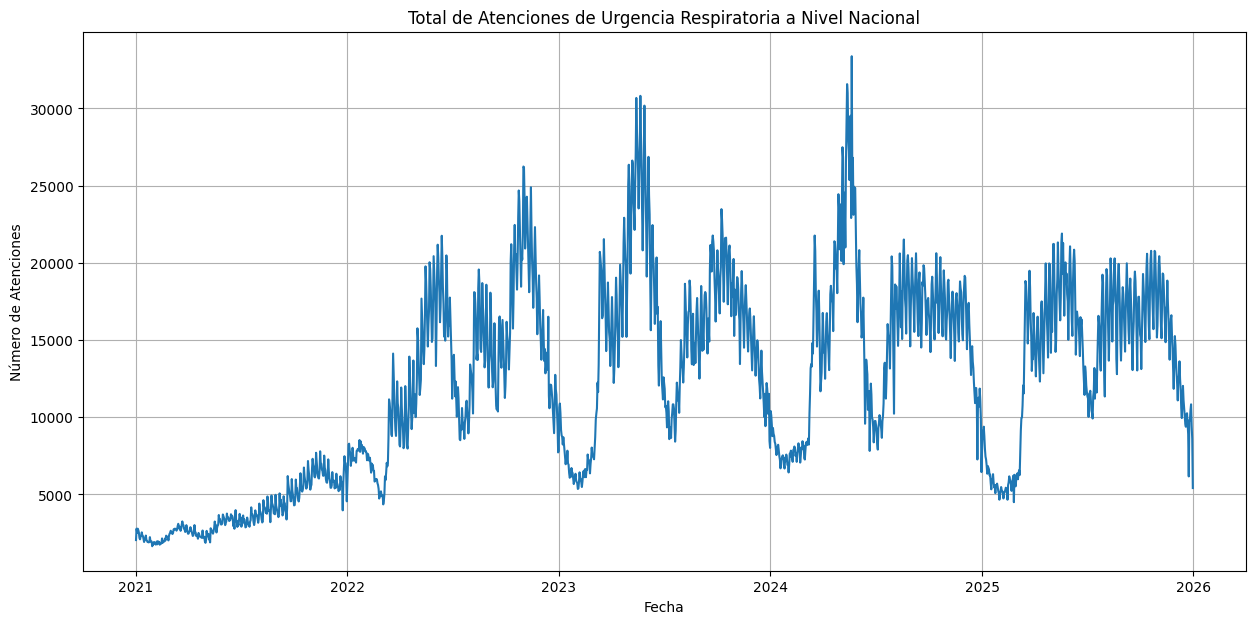

In [ ]:
# Creamos un gráfico de la serie de tiempo total diario
plt.figure(figsize=(15, 7))
plt.plot(ts_total_diario)
plt.title('Total de Atenciones de Urgencia Respiratoria a Nivel Nacional')
plt.xlabel('Fecha')
plt.ylabel('Número de Atenciones')
plt.grid(True)
plt.show()

fecha
2021-01-03     7340
2021-01-10    16900
2021-01-17    15500
2021-01-24    14030
2021-01-31    13365
Freq: W-SUN, Name: Total, dtype: int64


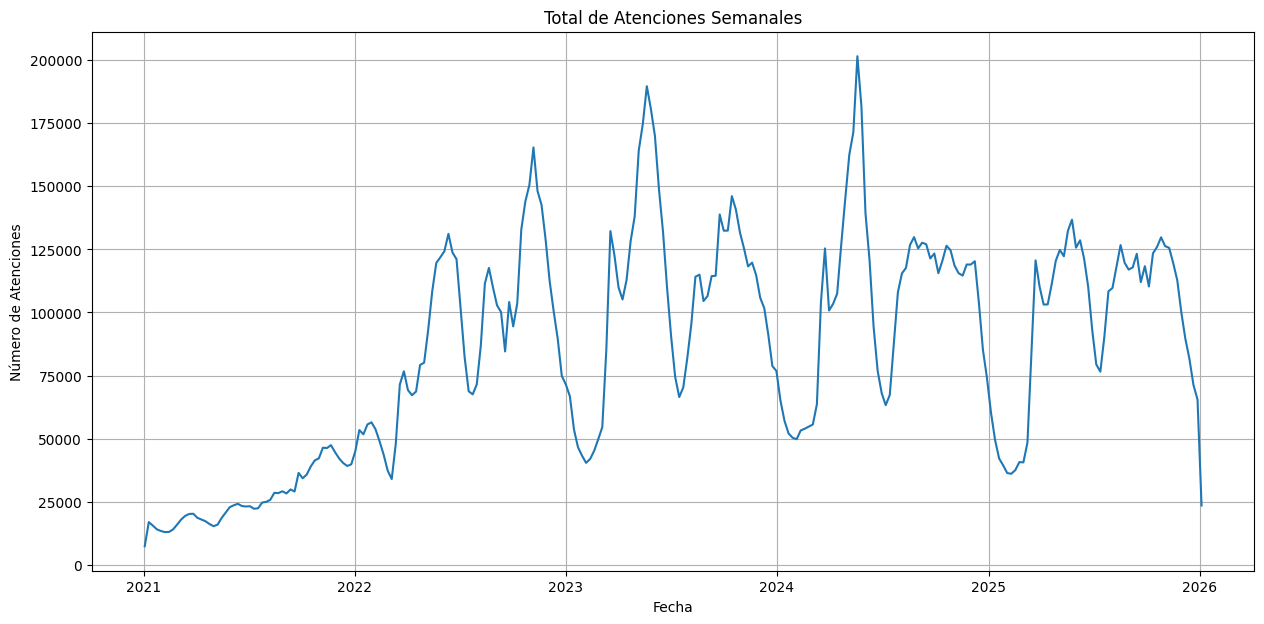

In [ ]:
# Re-muestreo a frecuencia semanal
ts_total_semanal = ts_total_diario.resample('W').sum()

# Mostramos el resultado
print(ts_total_semanal.head())

# Volvemos a graficar para ver la serie más suave
plt.figure(figsize=(15, 7))
plt.plot(ts_total_semanal)
plt.title('Total de Atenciones Semanales')
plt.xlabel('Fecha')
plt.ylabel('Número de Atenciones')
plt.grid(True)
plt.show()

In [ ]:
print("Total de Semanas que se utilizarán paraa el análisis: ", len(ts_total_semanal))

Total de Semanas que se utilizarán paraa el análisis:  262


            Menores_1  De_1_a_4  De_5_a_14  De_15_a_64  De_65_y_mas
fecha                                                              
2021-01-01        165       306        285        1020          271
2021-01-02        186       408        349        1487          356
2021-01-03        167       359        324        1339          318
2021-01-04        168       371        320        1582          343
2021-01-05        216       356        332        1474          309


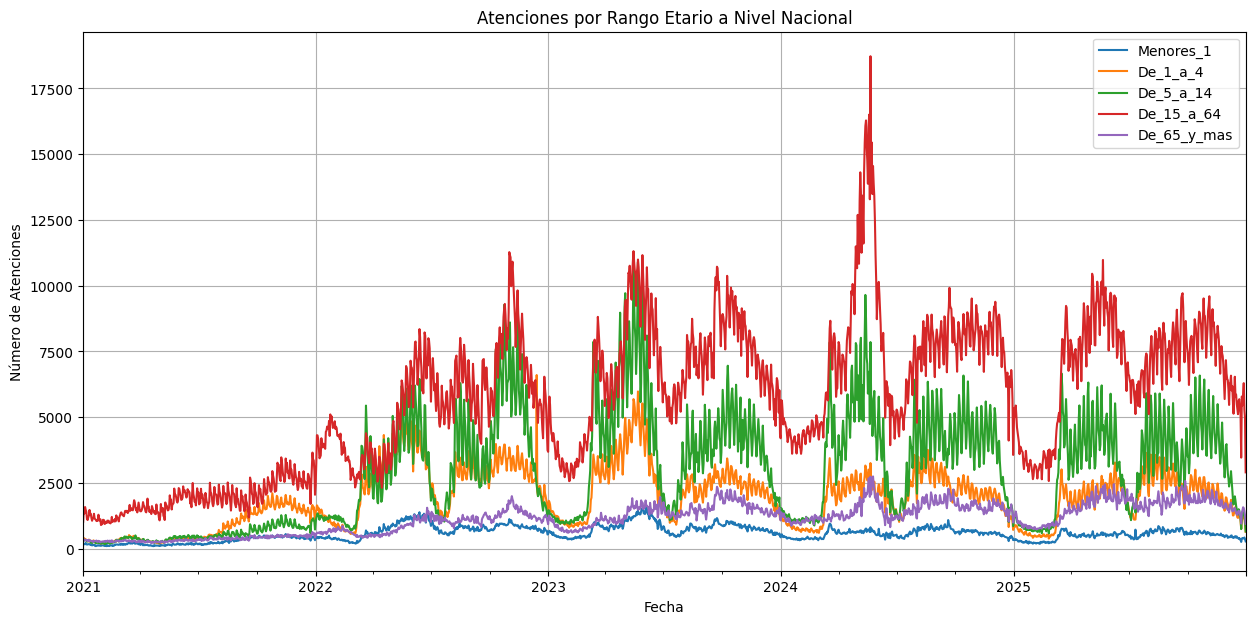

In [ ]:
# Definimos los grupos de edad de interés
grupos_etarios = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']

# Agrupamos por fecha y sumamos el total de cada grupo de edad
ts_etaria = au_respiratorias.groupby(au_respiratorias.index)[grupos_etarios].sum()

# Mostramos las primeras filas de la serie de tiempo por edad
print(ts_etaria.head())

# Graficamos la serie de tiempo para cada grupo de edad
ts_etaria.plot(figsize=(15, 7))
plt.title('Atenciones por Rango Etario a Nivel Nacional')
plt.xlabel('Fecha')
plt.ylabel('Número de Atenciones')
plt.grid(True)
plt.show()

In [ ]:
#Analizamos si losnombres de regiones están bien escritas, si no se corrigen

au_respiratorias['NombreRegion'].unique()


array(['Región Metropolitana de Santiago', 'Región de Los Lagos',
       'Región de La Araucanía', 'Región del Maule', 'Región del Bíobío',
       'Región de Tarapacá',
       'Región de Aysén del General Carlos Ibañez del Campo',
       'Región de Los Ríos', 'Región de Ñuble', 'Región de Valparaíso',
       'Región de Atacama', "Región del Libertador Gral. B. O'Higgins",
       'No Identificado', 'Región de Arica Parinacota',
       'Región de Antofagasta', 'Región de Coquimbo',
       'Región de Magallanes y de la Antártica Chilena',
       'Metropolitana de Santiago', 'Del BÃ\xadobÃ\xado', 'De TarapacÃ¡',
       'Del Maule', 'De Antofagasta', 'De ValparaÃ\xadso', 'De Ã\x91uble',
       'De Los Lagos', 'De Coquimbo', "Del Libertador B. O'Higgins",
       'De Los RÃ\xados', 'De Atacama', 'De Arica y Parinacota',
       'De La AraucanÃ\xada', 'De AisÃ©n del Gral. C. IbÃ¡Ã±ez del Campo',
       'De Magallanes y de La AntÃ¡rtica Chilena'], dtype=object)

In [ ]:
#Estandarizamos los nombres de las regiones
au_respiratorias['NombreRegion'].replace('Metropolitana de Santiago', 'Región Metropolitana de Santiago', inplace=True)
au_respiratorias['NombreRegion'].replace("Del BÃ\xadobÃ\xado", 'Región del Bíobío', inplace=True)
au_respiratorias['NombreRegion'].replace('De TarapacÃ¡', 'Región de Tarapacá', inplace=True)
au_respiratorias['NombreRegion'].replace('Del Maule', 'Región del Maule', inplace=True)
au_respiratorias['NombreRegion'].replace('De Antofagasta', 'Región de Antofagasta', inplace=True)
au_respiratorias['NombreRegion'].replace('De ValparaÃ\xadso', 'Región de Valparaíso', inplace=True)
au_respiratorias['NombreRegion'].replace('De Ã\x91uble', 'Región de Ñuble', inplace=True)
au_respiratorias['NombreRegion'].replace('De Los Lagos', 'Región de Los Lagos', inplace=True)
au_respiratorias['NombreRegion'].replace('De Coquimbo', 'Región de Coquimbo', inplace=True)
au_respiratorias['NombreRegion'].replace("Del Libertador B. O'Higgins", "Región del Libertador Gral. B. O'Higgins", inplace=True)
au_respiratorias['NombreRegion'].replace('De Los RÃ\xados', 'Región de Los Ríos', inplace=True)
au_respiratorias['NombreRegion'].replace("De Atacama", 'Región de Atacama', inplace=True)
au_respiratorias['NombreRegion'].replace('De Arica y Parinacota', 'Región de Arica Parinacota', inplace=True)
au_respiratorias['NombreRegion'].replace('De La AraucanÃ\xada', 'Región de La Araucanía', inplace=True)
au_respiratorias['NombreRegion'].replace('De AisÃ©n del Gral. C. IbÃ¡Ã±ez del Campo', 'Región de Aysén del General Carlos Ibañez del Campo', inplace=True)
au_respiratorias['NombreRegion'].replace('De Magallanes y de La AntÃ¡rtica Chilena', 'Región de Magallanes y de la Antártica Chilena', inplace=True)

au_respiratorias['NombreRegion'].unique()

/tmp/ipython-input-3560225726.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  au_respiratorias['NombreRegion'].replace('Metropolitana de Santiago', 'Región Metropolitana de Santiago', inplace=True)
/tmp/ipython-input-3560225726.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

array(['Región Metropolitana de Santiago', 'Región de Los Lagos',
       'Región de La Araucanía', 'Región del Maule', 'Región del Bíobío',
       'Región de Tarapacá',
       'Región de Aysén del General Carlos Ibañez del Campo',
       'Región de Los Ríos', 'Región de Ñuble', 'Región de Valparaíso',
       'Región de Atacama', "Región del Libertador Gral. B. O'Higgins",
       'No Identificado', 'Región de Arica Parinacota',
       'Región de Antofagasta', 'Región de Coquimbo',
       'Región de Magallanes y de la Antártica Chilena'], dtype=object)

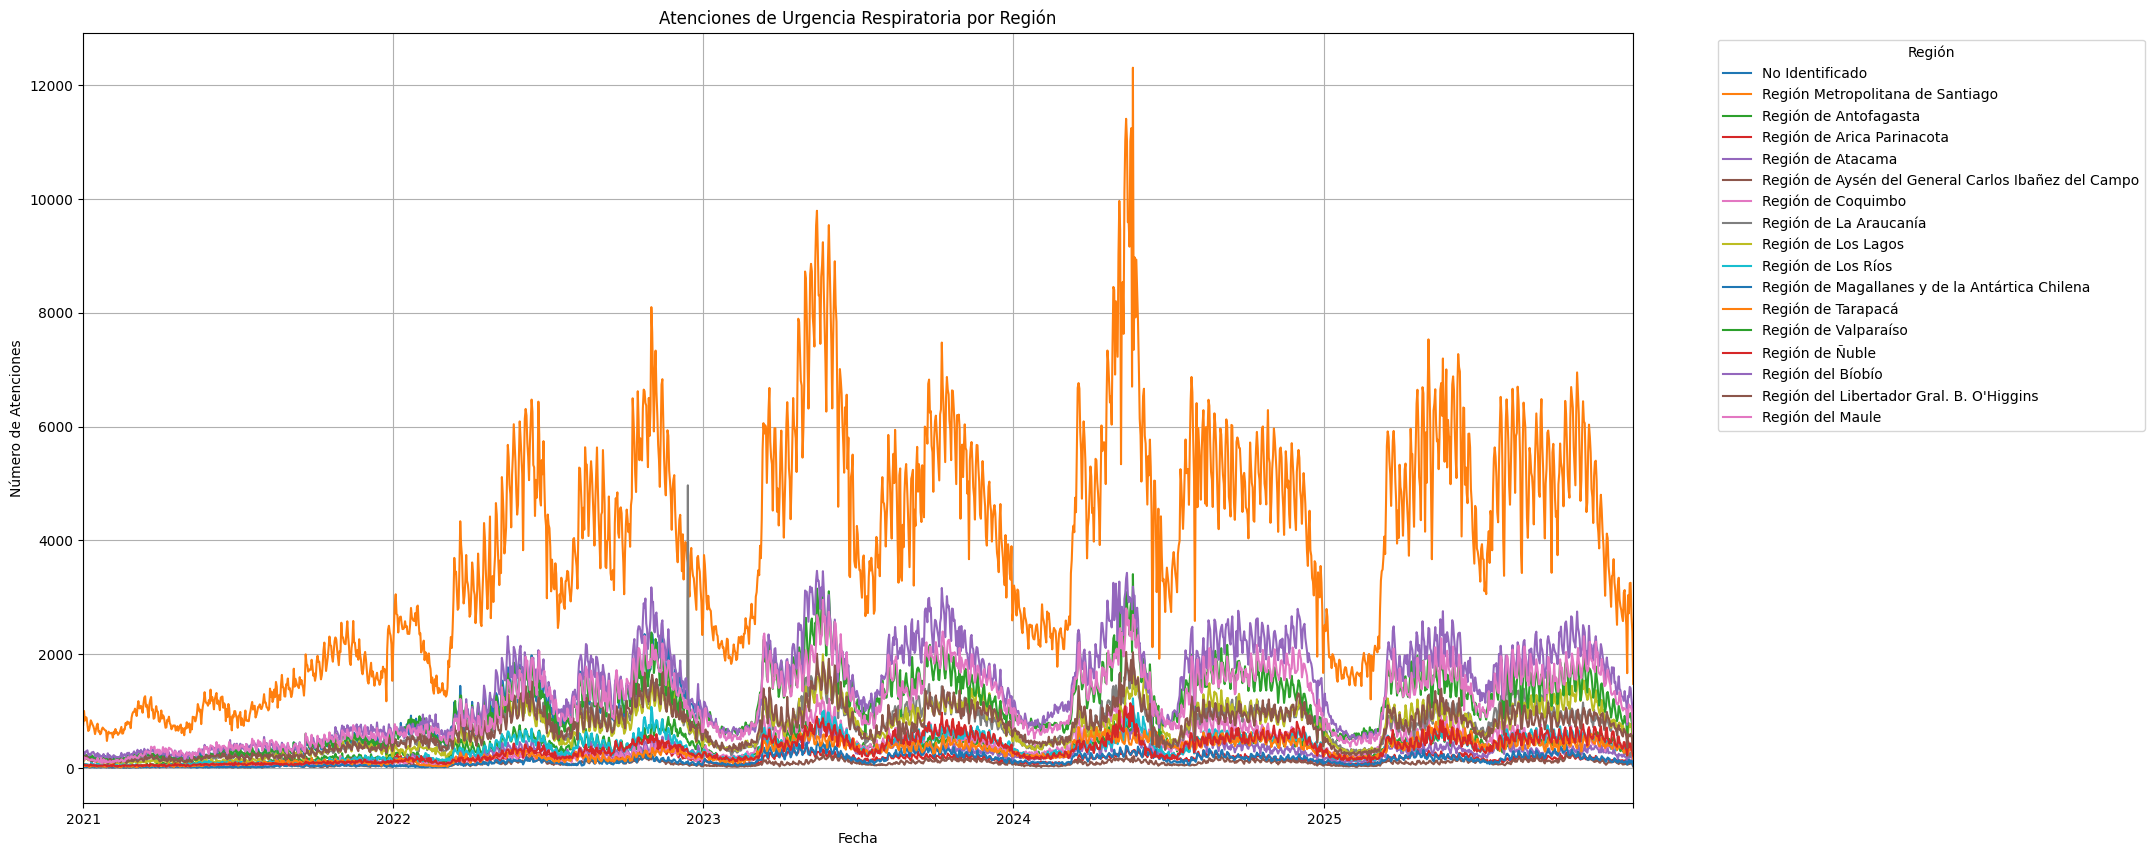

In [ ]:
#Agrupamos por región
ts_regional_diaria = au_respiratorias.groupby(['NombreRegion', pd.Grouper(freq='D')])['Total'].sum().unstack(level=0)
plt.figure(figsize=(20, 10))

# Graficamos todas las columnas (todas las regiones)
ts_regional_diaria.plot(ax=plt.gca())

plt.title('Atenciones de Urgencia Respiratoria por Región')
plt.xlabel('Fecha')
plt.ylabel('Número de Atenciones')
plt.grid(True)
plt.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

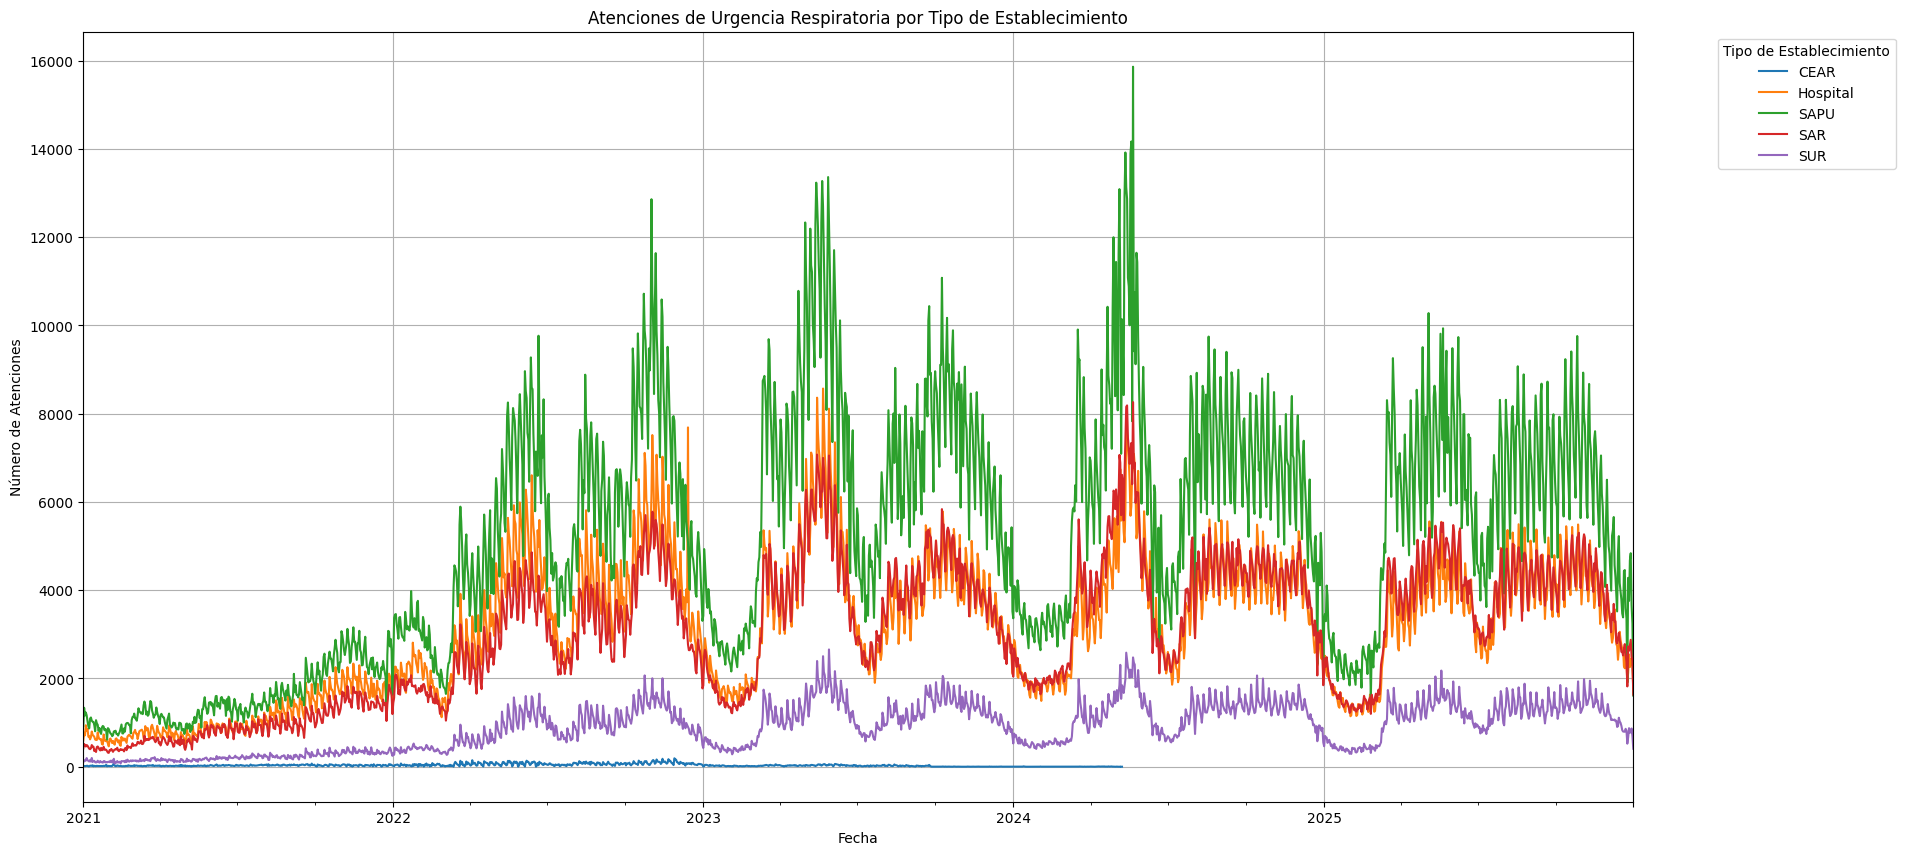

In [ ]:
# Agrupamos por tipo de establecimiento y fecha (índice), y sumamos el total de atenciones
ts_por_tipo = au_respiratorias.groupby(['GLOSATIPOESTABLECIMIENTO', pd.Grouper(freq='D')])['Total'].sum().unstack(level=0)

# Configuramos el tamaño del gráfico
plt.figure(figsize=(20, 10))

# Graficamos todas las series de tiempo del DataFrame
ts_por_tipo.plot(ax=plt.gca())

plt.title('Atenciones de Urgencia Respiratoria por Tipo de Establecimiento')
plt.xlabel('Fecha')
plt.ylabel('Número de Atenciones')
plt.grid(True)
plt.legend(title='Tipo de Establecimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Estadísticas descriptivas de la serie semanal
ts_total_diario2 = au_respiratorias.groupby('fecha')['Total'].sum()
ts_total_semanal_est = ts_total_diario2.resample('W').sum()

# Calculamos las estadísticas descriptivas
estadisticas = {
    'Media': ts_total_semanal.mean(),
    'Desviación Estándar': ts_total_semanal.std(),
    'Valor Mínimo': ts_total_semanal.min(),
    'Valor Máximo': ts_total_semanal.max()
}
# Imprimimos los resultados
print("Estadísticas Descriptivas de la Serie de Tiempo Semanal (a nivel nacional):")
print(pd.Series(estadisticas))

Estadísticas Descriptivas de la Serie de Tiempo Semanal (a nivel nacional):
Media                   85257.007634
Desviación Estándar     43417.933284
Valor Mínimo             7340.000000
Valor Máximo           201586.000000
dtype: float64


In [ ]:
ts_total_diario2

,Total
fecha,
2021-01-01,2047
2021-01-02,2786
2021-01-03,2507
2021-01-04,2784
2021-01-05,2687
...,...
2025-12-27,10462
2025-12-28,10838
2025-12-29,9480


El modelo aditivo asume que la serie de tiempo es la suma de sus componentes:

Y(t)=T(t)+S(t)+R(t)

Donde:

<br>Y(t) es el valor observado.

<br>T(t) es la tendencia.

<br>S(t) es la estacionalidad.

<br>R(t) son los residuos (o ruido).

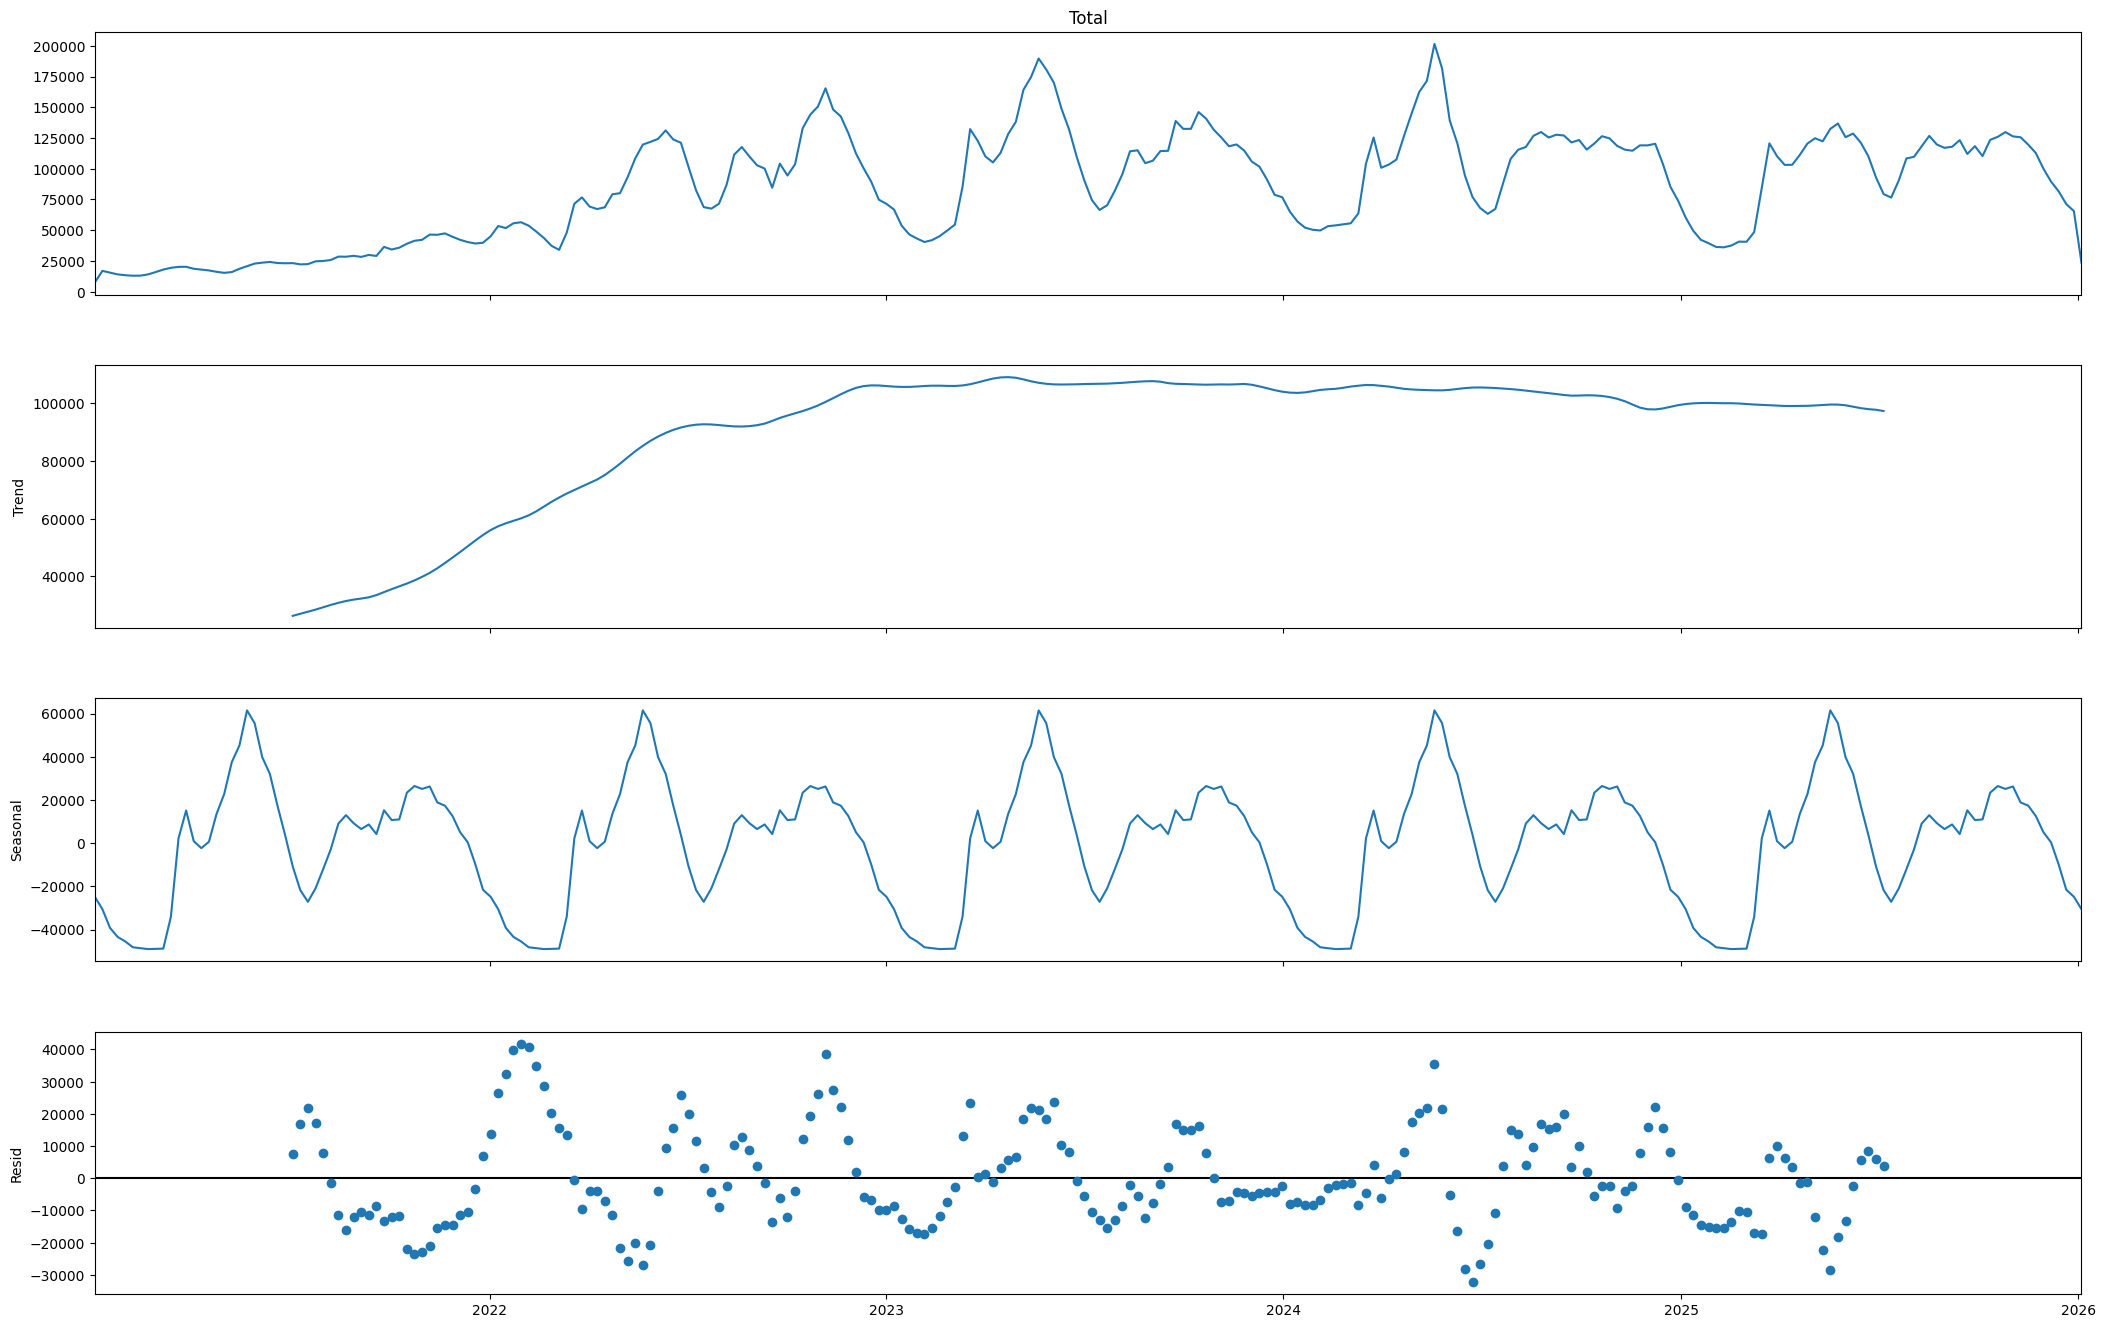

In [ ]:
#Analicemos las otras componenetes de la serie de tiempo

ts_total_semanal = ts_total_diario.resample('W').sum()
# Realizamos la descomposición. 'additive' es la más adecuada para datos de salud.
result = seasonal_decompose(ts_total_semanal, model='additive')


# Graficamos la descomposición con tamaño grande
fig = result.plot()
fig.set_size_inches(25, 15)  # ancho x alto
plt.show()

In [ ]:
au_respiratorias.to_csv('AtencionesUrgenciaResp.csv', index=False)  #correr solo para guardara el csv

ANALISIS DE ESTACIONARIEDAD

In [ ]:
#Analizamos estacionariedad de la serie de tiempo

print("Resumen de la Serie de Tiempo (ST) de Urgencias Diarias:")
print(ts_total_semanal.head())
print(f"La serie abarca {len(ts_total_semanal)} días.")

Resumen de la Serie de Tiempo (ST) de Urgencias Diarias:
fecha
2021-01-03     7340
2021-01-10    16900
2021-01-17    15500
2021-01-24    14030
2021-01-31    13365
Freq: W-SUN, Name: Total, dtype: int64
La serie abarca 262 días.


In [ ]:
#Aplicar la Prueba de Dickey-Fuller Aumentada (ADF)
print("\n--- Prueba de Dickey-Fuller Aumentada (ADF) ---")
adf_result = adfuller(ts_total_semanal, autolag='AIC')

# Formateamos y mostramos resultados
print(f'Estadístico ADF: {adf_result[0]:.4f}')
print(f'P-valor: {adf_result[1]:.4f}')
print('Valores Críticos (Niveles de Confianza):')
for key, value in adf_result[4].items():
    print(f'  {key}: {value:.4f}')


if adf_result[1] <= 0.05:
    print("\nConclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo es estacionaria.")
else:
    print("\nConclusión: El P-valor es > 0.05. NO se rechaza H0, la serie de tiempo NO es estacionaria. Se requerirá diferenciación.")


--- Prueba de Dickey-Fuller Aumentada (ADF) ---
Estadístico ADF: -3.5771
P-valor: 0.0062
Valores Críticos (Niveles de Confianza):
  1%: -3.4558
  5%: -2.8727
  10%: -2.5727

Conclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo es estacionaria.


In [ ]:
# Aplicar el Test KPSS. Usamos 'c' (constante) para probar la estacionariedad alrededor de la media
print("\n--- Test KPSS ---")
kpss_result = kpss(ts_total_semanal, regression='c', nlags='auto')

# Formateamos y mostramos resultados
print(f'Estadístico KPSS: {kpss_result[0]:.4f}')
print(f'P-valor: {kpss_result[1]:.4f}')
print('Valores Críticos (Niveles de Confianza):')
for key, value in kpss_result[3].items():
    print(f'  {key}: {value:.4f}')

if kpss_result[1] > 0.05:
    print("\nConclusión: El P-valor es > 0.05. NO se rechaza H0, la serie de tiempo es ESTACIONARIA.")
else:
    print("\nConclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo NO es ESTACIONARIA. Se requiere diferenciación.")


--- Test KPSS ---
Estadístico KPSS: 1.1150
P-valor: 0.0100
Valores Críticos (Niveles de Confianza):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Conclusión: El P-valor es <= 0.05. Se rechaza H0, la serie de tiempo NO es ESTACIONARIA. Se requiere diferenciación.


/tmp/ipython-input-2372609586.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts_total_semanal, regression='c', nlags='auto')


Al demostrar que la serie es no estacionaria realizaremos la diferenciacin para eliminar la no estacionariedad y forzar a la serie a ser estacionaria (eliminamos tendencia)

In [ ]:
#Aplicamos la diferenciación de orden 1
ts_total_semanal_diff = ts_total_semanal.diff().dropna()
print(f"Serie diferenciada abarca: {len(ts_total_semanal_diff)} días.")

#Prueba ADF en la serie diferenciada
print("\n--- Prueba ADF en Serie Diferenciada (d=1) ---")
adf_diff_result = adfuller(ts_total_semanal_diff, autolag='AIC')
print(f'Estadístico ADF: {adf_diff_result[0]:.4f}')
print(f'P-valor: {adf_diff_result[1]:.4f}')
if adf_diff_result[1] <= 0.05:
    print("Conclusión: La serie diferenciada ES ESTACIONARIA.")
else:
    print("Conclusión: La serie diferenciada NO ES ESTACIONARIA (se requeriría d=2).")

#Test KPSS en la serie diferenciada
print("\n--- Test KPSS en Serie Diferenciada (d=1) ---")
kpss_diff_result = kpss(ts_total_semanal_diff, regression='c', nlags='auto')
print(f'Estadístico KPSS: {kpss_diff_result[0]:.4f}')
print(f'P-valor: {kpss_diff_result[1]:.4f}')
if kpss_diff_result[1] > 0.05:
    print("Conclusión: La serie diferenciada ES ESTACIONARIA.")
else:
    print("Conclusión: La serie diferenciada NO ES ESTACIONARIA.")

Serie diferenciada abarca: 261 días.

--- Prueba ADF en Serie Diferenciada (d=1) ---
Estadístico ADF: -6.3378
P-valor: 0.0000
Conclusión: La serie diferenciada ES ESTACIONARIA.

--- Test KPSS en Serie Diferenciada (d=1) ---
Estadístico KPSS: 0.0923
P-valor: 0.1000
Conclusión: La serie diferenciada ES ESTACIONARIA.


/tmp/ipython-input-4069961623.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff_result = kpss(ts_total_semanal_diff, regression='c', nlags='auto')


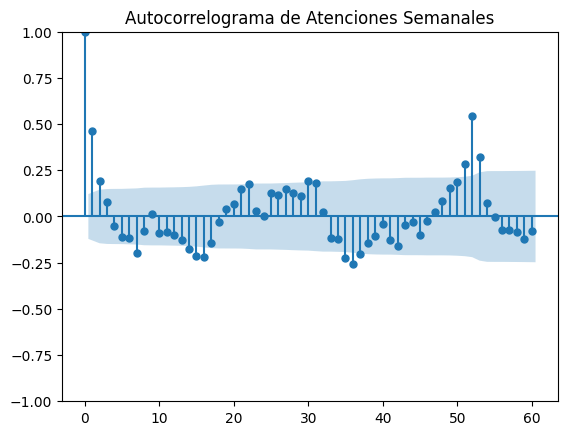

In [ ]:
# Graficamos el autocorrelograma
# Usamos un 'lags' de 60
plot_acf(ts_total_semanal_diff, lags=60, title='Autocorrelograma de Atenciones Semanales')
plt.show()

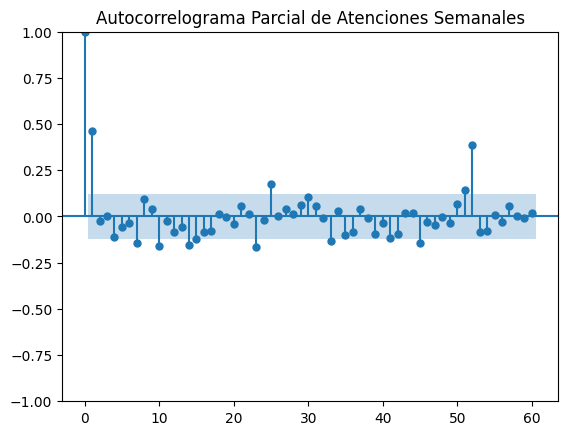

In [ ]:
# Graficamos el autocorrelograma parcial de la serie semanal
plot_pacf(ts_total_semanal_diff, lags=60, title='Autocorrelograma Parcial de Atenciones Semanales')
plt.show()

1. INTERPRETACIÓN DEL ACF (Autocorrelación)
 Observaciones clave:

Lag 1 positivo fuerte (~0.45)
→ indica estructura MA o AR de corto plazo
→ sugiere q = 1

Picos potentes en lag 52 (~0.50)
→ clarísima estacionalidad anual, con fuerza MA estacional
→ sugiere Q = 1

No hay cortes bruscos adicionales → no sugiere q altos

 Conclusión desde el ACF:

Componente no estacional: q = 1

Componente estacional: Q = 1

 2. INTERPRETACIÓN DEL PACF (Autocorrelación parcial)
 Observaciones clave:

Lag 1 significativo (~0.45)
→ estructura AR de corto plazo
→ sugiere p = 1

Lag 52 con pico moderado (~0.35)
→ indica componente AR estacional
→ sugiere P = 1

El resto de lags dentro del intervalo → no hay necesidad de p > 1 ni P > 1

 Conclusión desde el PACF:

Componente no estacional: p = 1

Componente estacional: P = 1

 3. ORDENES FINALES DEL MODELO (según los tests)

Ya determinamos:

✔ Diferencia no estacional

→ d = 1 (por ADF y KPSS)

✔ Diferencia estacional

→ D = 1 (por patrón fuerte en lag 52)

In [ ]:
urg=au_respiratorias.reset_index()


In [ ]:
urg.isnull().sum()

fecha                       0
IdEstablecimiento           0
NEstablecimiento            0
Total                       0
Menores_1                   0
De_1_a_4                    0
De_5_a_14                   0
De_15_a_64                  0
De_65_y_mas                 0
semana                      0
GLOSATIPOESTABLECIMIENTO    0
CodigoRegion                0
NombreRegion                0
CodigoComuna                0
NombreComuna                0
Anio                        0
Semana                      0
dtype: int64

In [ ]:
urg['fecha'] = pd.to_datetime(urg['fecha'])

urg['Semana'] = (
    urg['fecha']
    .dt.to_period('W-MON')
    .apply(lambda r: r.start_time)
)


urgencias_procesadas = (
    urg
    .groupby(['NombreRegion', 'Semana'])['Total']
    .sum()
    .reset_index()
    .rename(columns={'Total': 'Atenciones_Urg', 'NombreRegion': 'RegionNombre'})
)


print("Columnas finales:", urgencias_procesadas.columns.tolist())
print(urgencias_procesadas.head())



Columnas finales: ['RegionNombre', 'Semana', 'Atenciones_Urg']
      RegionNombre     Semana  Atenciones_Urg
0  No Identificado 2020-12-29             771
1  No Identificado 2021-01-05            1365
2  No Identificado 2021-01-12            1272
3  No Identificado 2021-01-19            1131
4  No Identificado 2021-01-26            1111


In [ ]:
urgencias_procesadas

,RegionNombre,Semana,Atenciones_Urg
0,No Identificado,2020-12-29,771
1,No Identificado,2021-01-05,1365
2,No Identificado,2021-01-12,1272
3,No Identificado,2021-01-19,1131
4,No Identificado,2021-01-26,1111
...,...,...,...
4292,Región del Maule,2025-12-02,9817
4293,Región del Maule,2025-12-09,8509
4294,Región del Maule,2025-12-16,7557
4295,Región del Maule,2025-12-23,7048


In [ ]:
#Exportamos a CSV
urgencias_procesadas.to_csv("urgencias_procesadas.csv", index=False)